In [15]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

warnings.filterwarnings("ignore")

matplotlib.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    # B&W safe
    "axes.prop_cycle": matplotlib.cycler(color=["#111111","#555555","#999999","#CCCCCC"]),
    "hatch.linewidth": 0.6,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})
CLASS_COLORS  = {"hate": "#111111", "offensive": "#888888", "normal": "#CCCCCC"}
OCULA_ORDER   = ["hate", "offensive", "normal"]
INT_TO_STR    = {0: "hate", 1: "offensive", 2: "normal"}
SOURCE_ORDER  = ["hatexplain", "davidson", "hasoc_english", "hasoc_hindi", "indo_hate"]
SOURCE_COLORS = {
    "hatexplain":    "#111111",
    "davidson":      "#444444",
    "hasoc_english": "#777777",
    "hasoc_hindi":   "#AAAAAA",
    "indo_hate":     "#DDDDDD",
}
LANG_COLORS  = {"en": "#111111", "hi": "#777777", "hi-Latn": "#CCCCCC"}
PLOT_DIR      = "./plots/combined"
os.makedirs(PLOT_DIR, exist_ok=True)

print("✓ Imports complete")

✓ Imports complete


In [16]:
train = pd.read_csv("../data/splits/train.csv")
val   = pd.read_csv("../data/splits/val.csv")
test  = pd.read_csv("../data/splits/test.csv")

train["split"] = "train"
val["split"]   = "val"
test["split"]  = "test"

df = pd.concat([train, val, test], ignore_index=True)
df["word_count"] = df["text"].astype(str).str.split().str.len()

print(f"Train : {len(train):>7,} rows")
print(f"Val   : {len(val):>7,} rows")
print(f"Test  : {len(test):>7,} rows")
print(f"Total : {len(df):>7,} rows")
print(f"\nColumns: {list(df.columns)}")
df.head(3)

Train :  82,774 rows
Val   :  10,336 rows
Test  :  10,346 rows
Total : 103,456 rows

Columns: ['text', 'label_int', 'label_str', 'source', 'lang', 'split', 'word_count']


,text,label_int,label_str,source,lang,split,word_count
0,he is going wherever jews take him israel firs...,2,normal,hatexplain,en,train,11
1,<user> he exactly the type to say ah ha ha do ...,2,normal,hatexplain,en,train,19
2,"""[user]: i'm dre's a bitch tho"" [smirking_face]",1,offensive,davidson,en,train,7


In [17]:
src_counts = df["source"].value_counts().reindex(SOURCE_ORDER, fill_value=0)
total      = len(df)

print(f"{'Source':<18} {'Count':>8}  {'% of total':>10}")
print("-" * 42)
for src in SOURCE_ORDER:
    cnt = src_counts[src]
    print(f"{src:<18} {cnt:>8,}  {cnt/total*100:>9.1f}%")
print(f"\n{'TOTAL':<18} {total:>8,}  {'100.0%':>10}")

Source                Count  % of total
------------------------------------------
hatexplain           20,105       19.4%
davidson             24,401       23.6%
hasoc_english         5,739        5.5%
hasoc_hindi           4,644        4.5%
indo_hate            48,567       46.9%

TOTAL               103,456      100.0%


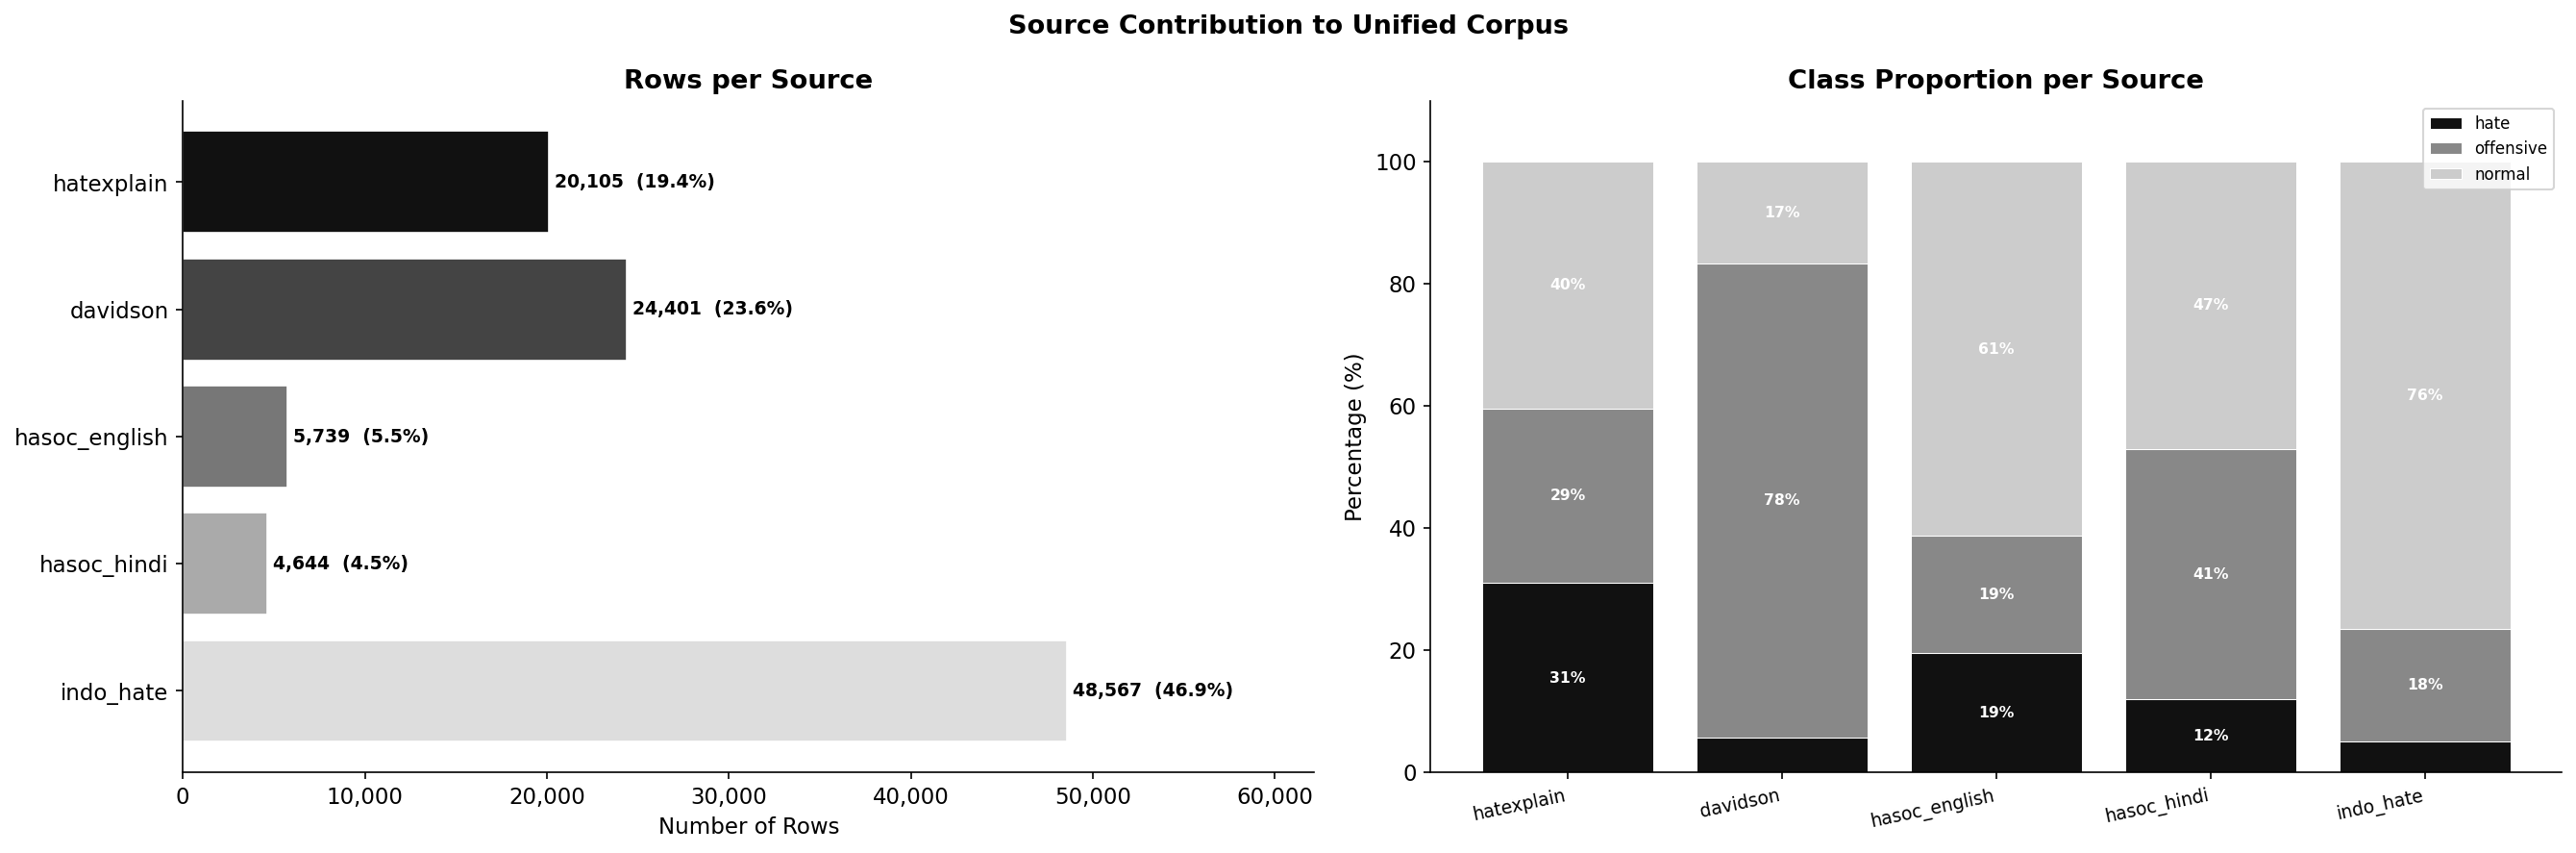

✓ Saved 01_source_contribution.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Source Contribution to Unified Corpus", fontsize=13, fontweight="bold")

# Horizontal bar — total rows per source
ax = axes[0]
colors = [SOURCE_COLORS[s] for s in SOURCE_ORDER]
bars = ax.barh(SOURCE_ORDER, [src_counts[s] for s in SOURCE_ORDER],
               color=colors, edgecolor="white", linewidth=0.8)
for bar, src in zip(bars, SOURCE_ORDER):
    v = src_counts[src]
    ax.text(bar.get_width() + total * 0.003, bar.get_y() + bar.get_height()/2,
            f"{v:,}  ({v/total*100:.1f}%)",
            va="center", fontsize=9, fontweight="bold")
ax.set_title("Rows per Source", fontweight="bold")
ax.set_xlabel("Number of Rows")
ax.set_xlim(0, src_counts.max() * 1.28)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Stacked bar — class proportion per source
ax = axes[1]
src_class = df.groupby(["source", "label_str"]).size().unstack(fill_value=0)
src_class  = src_class.reindex(SOURCE_ORDER)
for col in OCULA_ORDER:
    if col not in src_class.columns:
        src_class[col] = 0
src_class = src_class[OCULA_ORDER]

bottoms = np.zeros(len(SOURCE_ORDER))
x       = np.arange(len(SOURCE_ORDER))
for lbl in OCULA_ORDER:
    vals = src_class[lbl].values / src_class.sum(axis=1).values * 100
    bars = ax.bar(x, vals, bottom=bottoms,
                  label=lbl, color=CLASS_COLORS[lbl], edgecolor="white", linewidth=0.5)
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 6:
            ax.text(i, b + v/2, f"{v:.0f}%",
                    ha="center", va="center", fontsize=7.5, fontweight="bold", color="white")
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(SOURCE_ORDER, rotation=12, ha="right", fontsize=9)
ax.set_title("Class Proportion per Source", fontweight="bold")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 110)
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/01_source_contribution.png", bbox_inches="tight")
plt.show()
print("✓ Saved 01_source_contribution.png")

In [19]:
print(f"{'Class':<12} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print("-" * 48)
for lbl in OCULA_ORDER:
    tr  = (train["label_str"] == lbl).sum()
    v   = (val["label_str"]   == lbl).sum()
    te  = (test["label_str"]  == lbl).sum()
    tot = tr + v + te
    print(f"{lbl:<12} {tr:>8,} {v:>8,} {te:>8,} {tot:>8,}")
print("-" * 48)
print(f"{'TOTAL':<12} {len(train):>8,} {len(val):>8,} {len(test):>8,} {len(df):>8,}")

Class           Train      Val     Test    Total
------------------------------------------------
hate            9,405    1,175    1,176   11,756
offensive      29,336    3,663    3,666   36,665
normal         44,033    5,498    5,504   55,035
------------------------------------------------
TOTAL          82,774   10,336   10,346  103,456


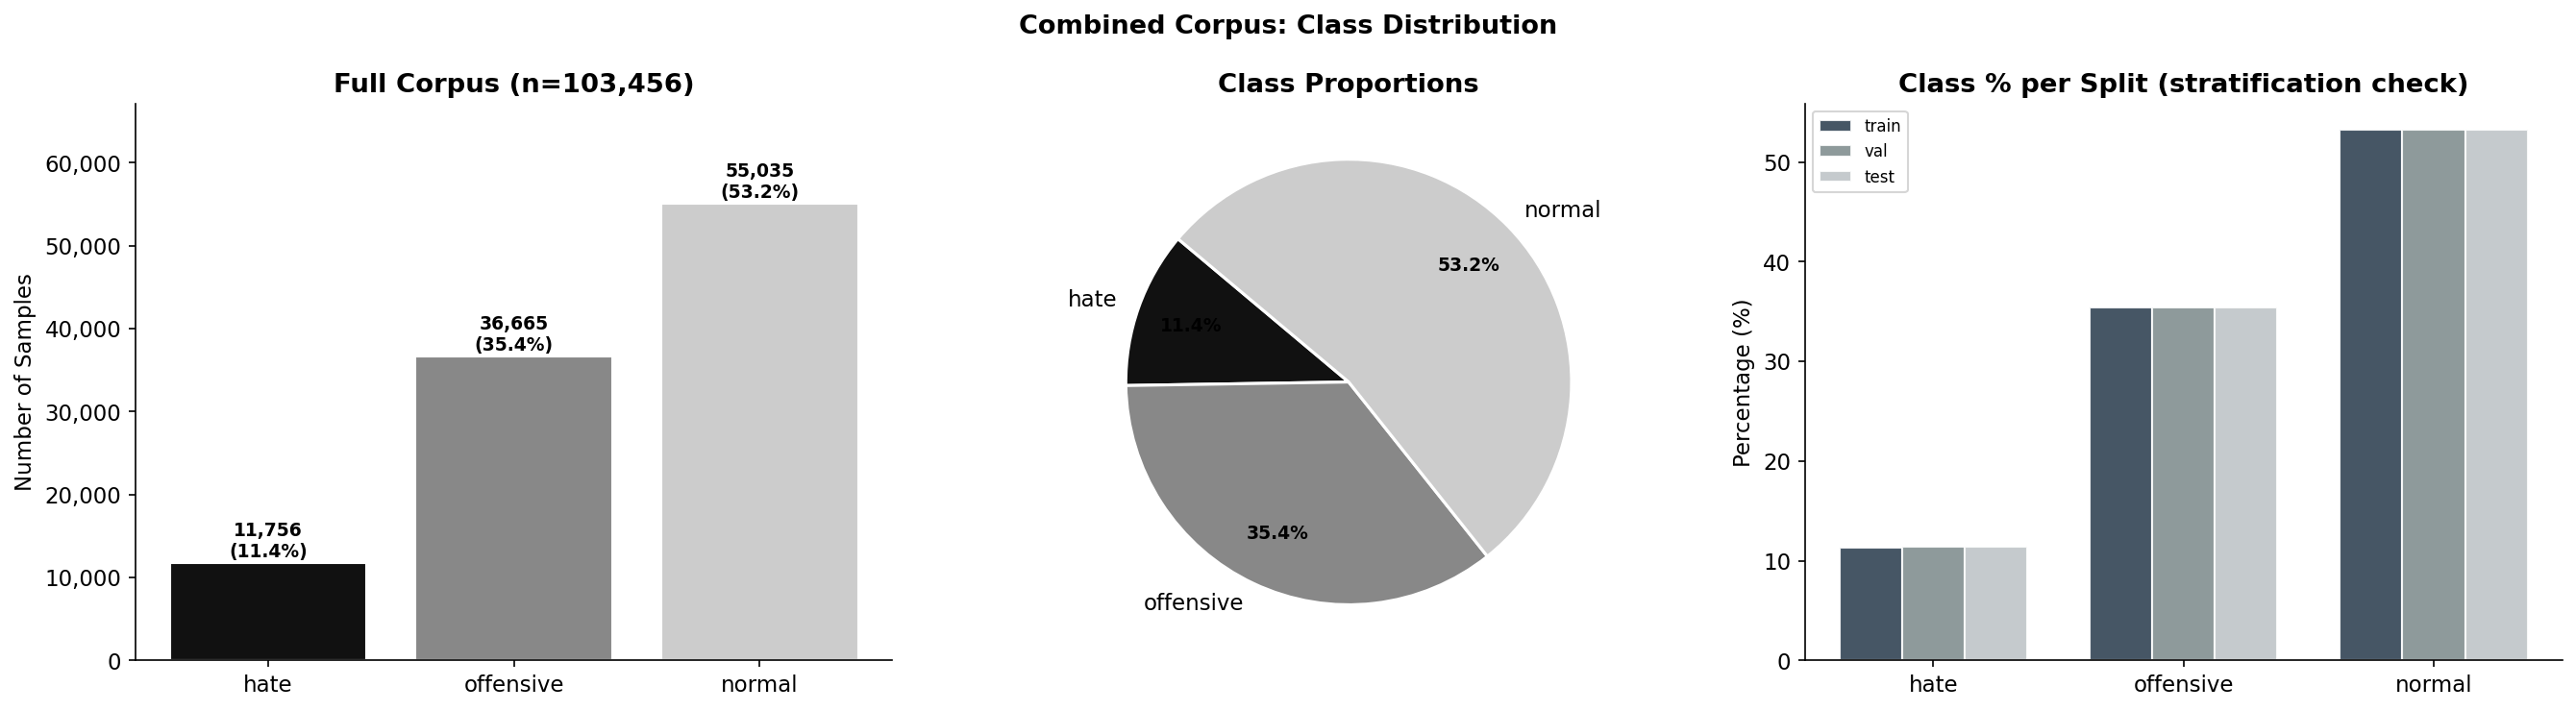

✓ Saved 02_class_distribution.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Combined Corpus: Class Distribution", fontsize=13, fontweight="bold")

# Full corpus bar
ax = axes[0]
vc     = df["label_str"].value_counts().reindex(OCULA_ORDER, fill_value=0)
colors = [CLASS_COLORS[l] for l in OCULA_ORDER]
bars   = ax.bar(OCULA_ORDER, vc.values, color=colors, edgecolor="white")
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f"{v:,}\n({v/len(df)*100:.1f}%)",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Full Corpus (n=103,456)", fontweight="bold")
ax.set_ylabel("Number of Samples")
ax.set_ylim(0, vc.max() * 1.22)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Pie
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    vc.values, labels=OCULA_ORDER, colors=colors,
    autopct="%1.1f%%", startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight("bold")
ax.set_title("Class Proportions", fontweight="bold")

# Train / Val / Test side-by-side
ax = axes[2]
splits     = [("train", train), ("val", val), ("test", test)]
split_names= [s[0] for s in splits]
x          = np.arange(len(OCULA_ORDER))
w          = 0.25
split_plot_colors = ["#2C3E50", "#7F8C8D", "#BDC3C7"]
for i, (sname, sdf) in enumerate(splits):
    vals = [( sdf["label_str"] == l).sum() / len(sdf) * 100 for l in OCULA_ORDER]
    ax.bar(x + (i-1)*w, vals, w, label=sname,
           color=split_plot_colors[i], edgecolor="white", alpha=0.88)
ax.set_xticks(x)
ax.set_xticklabels(OCULA_ORDER)
ax.set_title("Class % per Split (stratification check)", fontweight="bold")
ax.set_ylabel("Percentage (%)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/02_class_distribution.png", bbox_inches="tight")
plt.show()
print("✓ Saved 02_class_distribution.png")

In [21]:
lang_counts = df["lang"].value_counts()
print("Language distribution (full corpus):")
for lang, cnt in lang_counts.items():
    print(f"  {lang:<10}: {cnt:>7,}  ({cnt/len(df)*100:.1f}%)")

print("\nLanguage × Class crosstab (row %):")
ct = pd.crosstab(df["lang"], df["label_str"],
                 values=df["label_str"], aggfunc="count", margins=True)
ct_pct = pd.crosstab(df["lang"], df["label_str"], normalize="index") * 100
print(ct.to_string())
print()
print(ct_pct.round(1).to_string())

Language distribution (full corpus):
  en        :  50,245  (48.6%)
  hi-Latn   :  48,567  (46.9%)
  hi        :   4,644  (4.5%)

Language × Class crosstab (row %):
label_str   hate  normal  offensive     All
lang                                       
en          8746   15722      25777   50245
hi           553    2187       1904    4644
hi-Latn     2457   37126       8984   48567
All        11756   55035      36665  103456

label_str  hate  normal  offensive
lang                              
en         17.4    31.3       51.3
hi         11.9    47.1       41.0
hi-Latn     5.1    76.4       18.5


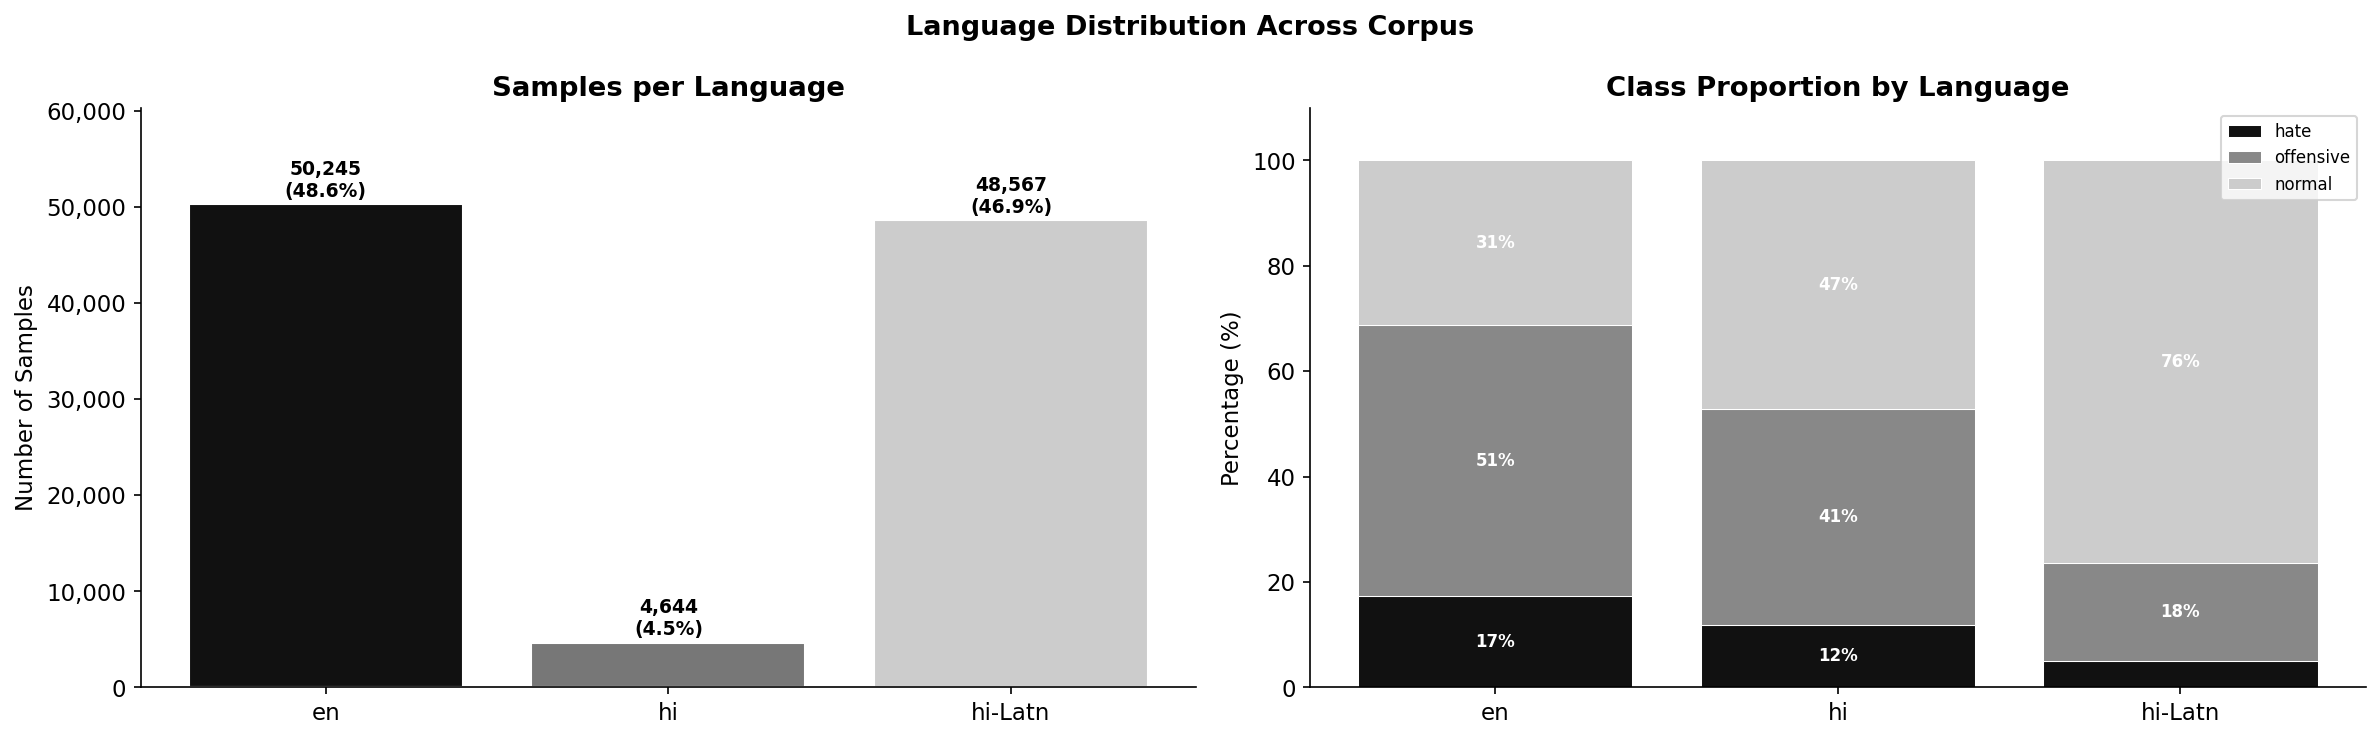

✓ Saved 03_language_distribution.png


In [22]:
LANG_ORDER = ["en", "hi", "hi-Latn"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Language Distribution Across Corpus", fontsize=13, fontweight="bold")

# Overall language bar
ax = axes[0]
lang_vals = [lang_counts.get(l, 0) for l in LANG_ORDER]
colors    = [LANG_COLORS[l] for l in LANG_ORDER]
bars      = ax.bar(LANG_ORDER, lang_vals, color=colors, edgecolor="white")
for bar, v in zip(bars, lang_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
            f"{v:,}\n({v/len(df)*100:.1f}%)",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Samples per Language", fontweight="bold")
ax.set_ylabel("Number of Samples")
ax.set_ylim(0, max(lang_vals) * 1.2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Language × class stacked
ax = axes[1]
lang_class = df.groupby(["lang", "label_str"]).size().unstack(fill_value=0)
lang_class  = lang_class.reindex(LANG_ORDER, fill_value=0)
for col in OCULA_ORDER:
    if col not in lang_class.columns:
        lang_class[col] = 0
lang_class  = lang_class[OCULA_ORDER]

bottoms = np.zeros(len(LANG_ORDER))
x       = np.arange(len(LANG_ORDER))
for lbl in OCULA_ORDER:
    vals = lang_class[lbl].values / lang_class.sum(axis=1).values * 100
    ax.bar(x, vals, bottom=bottoms,
           label=lbl, color=CLASS_COLORS[lbl], edgecolor="white", linewidth=0.5)
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 6:
            ax.text(i, b + v/2, f"{v:.0f}%",
                    ha="center", va="center", fontsize=8,
                    fontweight="bold", color="white")
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(LANG_ORDER)
ax.set_title("Class Proportion by Language", fontweight="bold")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 110)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/03_language_distribution.png", bbox_inches="tight")
plt.show()
print("✓ Saved 03_language_distribution.png")

In [23]:
print("Mean word count per source:")
for src in SOURCE_ORDER:
    sub = df[df["source"] == src]["word_count"]
    print(f"  {src:<18}: mean={sub.mean():.1f}  median={sub.median():.1f}")

Mean word count per source:
  hatexplain        : mean=23.6  median=21.0
  davidson          : mean=14.2  median=13.0
  hasoc_english     : mean=23.7  median=21.0
  hasoc_hindi       : mean=27.9  median=24.0
  indo_hate         : mean=9.6  median=7.0


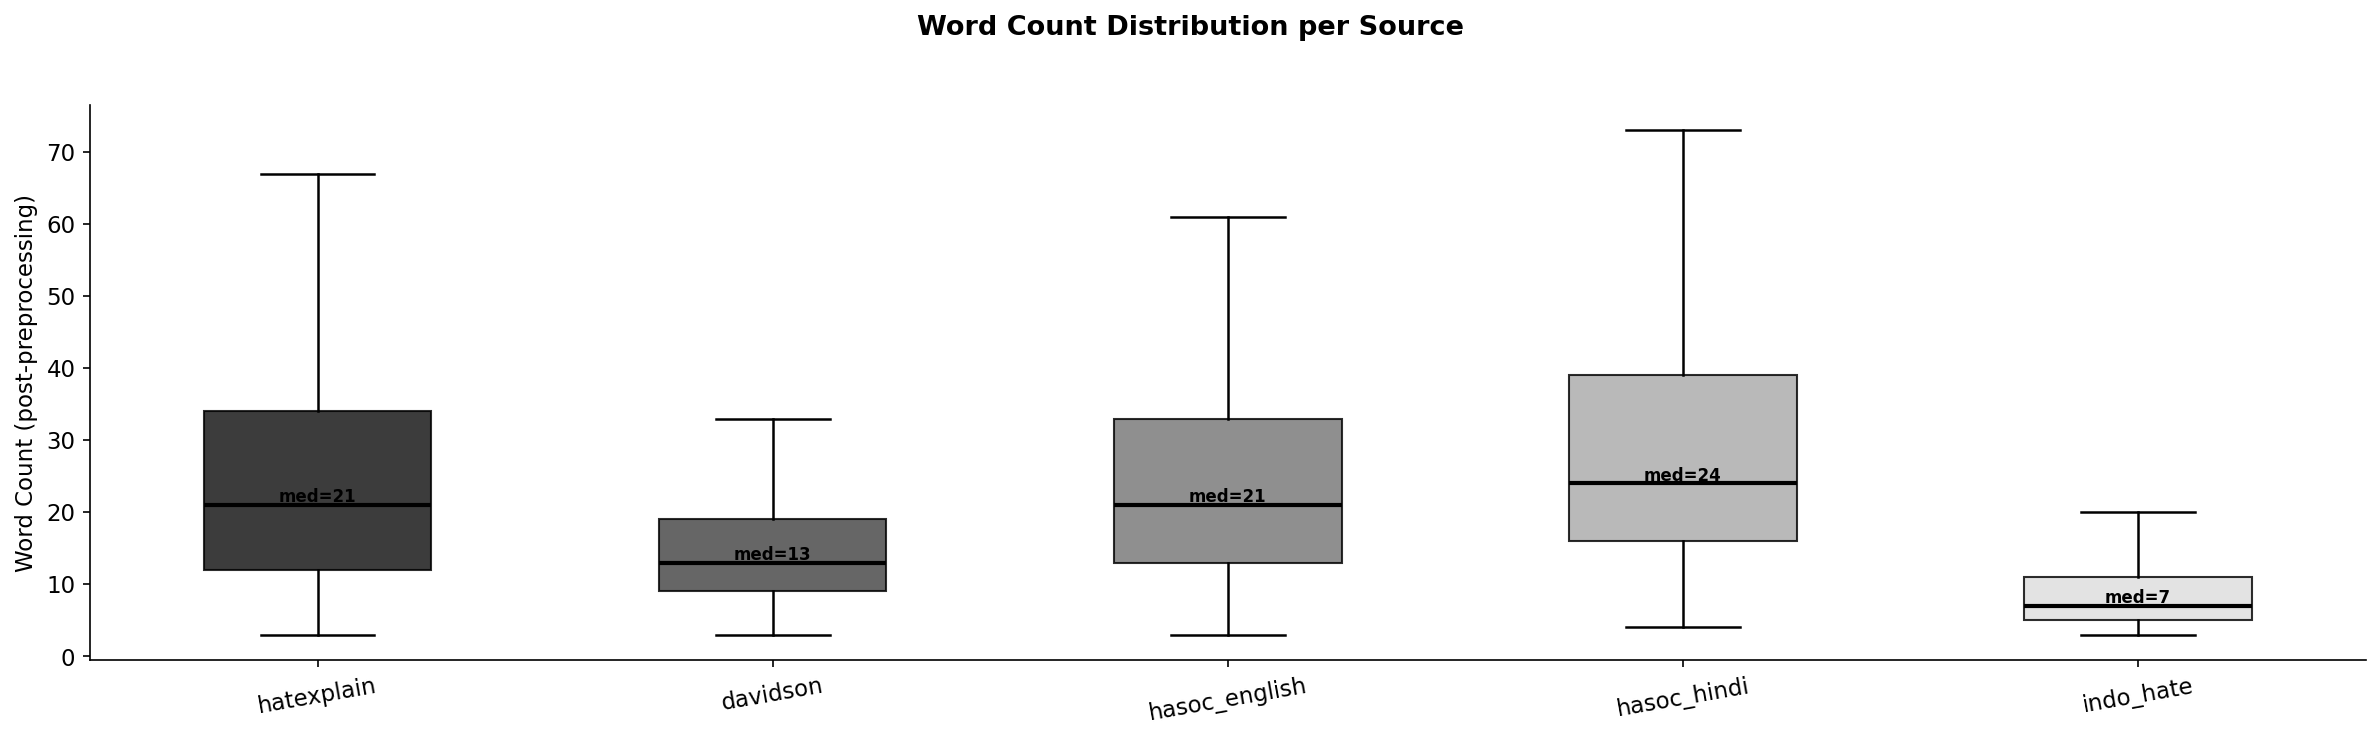

✓ Saved 04_word_count_per_source.png


In [24]:
fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle("Word Count Distribution per Source\n",
             fontsize=13, fontweight="bold")

groups = [df[df["source"] == s]["word_count"].values for s in SOURCE_ORDER]
colors = [SOURCE_COLORS[s] for s in SOURCE_ORDER]

bp = ax.boxplot(groups, patch_artist=True, notch=False,
                medianprops=dict(color="black", lw=2),
                whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.82)

ax.set_xticks(range(1, len(SOURCE_ORDER)+1))
ax.set_xticklabels(SOURCE_ORDER, rotation=10)
ax.set_ylabel("Word Count (post-preprocessing)")
ax.set_title("")

# Annotate medians
for i, src in enumerate(SOURCE_ORDER):
    med = np.median(groups[i])
    ax.text(i+1, med + 0.4, f"med={med:.0f}",
            ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/04_word_count_per_source.png", bbox_inches="tight")
plt.show()
print("✓ Saved 04_word_count_per_source.png")

In [25]:
BEFORE_DEDUP  = 109_462
AFTER_DEDUP   = 103_456  
REMOVED       = BEFORE_DEDUP - AFTER_DEDUP

# ── Actual duplicate count per source from the loaded data ─────────────────
print(f"Before deduplication : {BEFORE_DEDUP:>8,}")
print(f"After deduplication  : {len(df):>8,}")
print(f"Removed              : {REMOVED:>8,}  ({REMOVED/BEFORE_DEDUP*100:.1f}%)")
print(f"\nDuplicates found per source (exact, from loaded splits):")
print(f"{'Source':<18} {'Total rows':>10} {'Duplicates':>12} {'Dup %':>8}")
print("-" * 52)
total_dups = 0
for src in SOURCE_ORDER:
    sub  = df[df["source"] == src]["text"]
    dups = sub.duplicated().sum()
    total_dups += dups
    print(f"{src:<18} {len(sub):>10,} {dups:>12,} {dups/len(sub)*100:>7.1f}%")
print("-" * 52)
print(f"{'TOTAL':<18} {len(df):>10,} {total_dups:>12,} {total_dups/len(df)*100:>7.1f}%")

Before deduplication :  109,462
After deduplication  :  103,456
Removed              :    6,006  (5.5%)

Duplicates found per source (exact, from loaded splits):
Source             Total rows   Duplicates    Dup %
----------------------------------------------------
hatexplain             20,105            0     0.0%
davidson               24,401            0     0.0%
hasoc_english           5,739            0     0.0%
hasoc_hindi             4,644            0     0.0%
indo_hate              48,567            0     0.0%
----------------------------------------------------
TOTAL                 103,456            0     0.0%


In [27]:
# ── Per-source stats from the actual loaded data 
TRAIN_TOTAL   = 82_774
LABEL_COUNTS  = {0: 9_405, 1: 29_336, 2: 44_033}
LABEL_NAMES   = {0: "hate", 1: "offensive", 2: "normal"}

raw_alpha = {k: TRAIN_TOTAL / (3 * v) for k, v in LABEL_COUNTS.items()}
mean_a    = np.mean(list(raw_alpha.values()))
norm_alpha= {k: v / mean_a for k, v in raw_alpha.items()}

rows = []
for src in SOURCE_ORDER:
    sub   = df[df["source"] == src]
    lang  = sub["lang"].mode()[0] if len(sub) > 0 else "—"
    n     = len(sub)
    cls   = " / ".join(OCULA_ORDER)
    rows.append({"Dataset": src, "Language": lang,
                 "Rows": n, "Classes": "H/O/N", "Split": "merged"})

# Add total and split rows
rows.append({"Dataset": "TOTAL", "Language": "en + hi + hi-Latn",
             "Rows": len(df), "Classes": "H/O/N", "Split": "—"})
rows.append({"Dataset": "— Train", "Language": "—",
             "Rows": len(train), "Classes": "—", "Split": "80%"})
rows.append({"Dataset": "— Val",   "Language": "—",
             "Rows": len(val),   "Classes": "—", "Split": "10%"})
rows.append({"Dataset": "— Test",  "Language": "—",
             "Rows": len(test),  "Classes": "—", "Split": "10%"})

stats_df = pd.DataFrame(rows)

print("=" * 72)
print("  OCULA Combined Corpus : Summary Statistics")
print("=" * 72)
print(stats_df.to_string(index=False))
print("=" * 72)
print(f"\nClass distribution in full corpus:")
for lbl in OCULA_ORDER:
    cnt = (df["label_str"] == lbl).sum()
    print(f"  {lbl:<12}: {cnt:>7,}  ({cnt/len(df)*100:.1f}%)")
print(f"\nTrain focal loss alpha weights (normalized, mean=1):")
for k in [0, 1, 2]:
    print(f"  {LABEL_NAMES[k]:<12}: α = {norm_alpha[k]:.4f}  "
          f"(count={LABEL_COUNTS[k]:,})")

  OCULA Combined Corpus : Summary Statistics
      Dataset          Language   Rows Classes  Split
   hatexplain                en  20105   H/O/N merged
     davidson                en  24401   H/O/N merged
hasoc_english                en   5739   H/O/N merged
  hasoc_hindi                hi   4644   H/O/N merged
    indo_hate           hi-Latn  48567   H/O/N merged
        TOTAL en + hi + hi-Latn 103456   H/O/N      —
      — Train                 —  82774       —    80%
        — Val                 —  10336       —    10%
       — Test                 —  10346       —    10%

Class distribution in full corpus:
  hate        :  11,756  (11.4%)
  offensive   :  36,665  (35.4%)
  normal      :  55,035  (53.2%)

Train focal loss alpha weights (normalized, mean=1):
  hate        : α = 1.9554  (count=9,405)
  offensive   : α = 0.6269  (count=29,336)
  normal      : α = 0.4177  (count=44,033)
